***Sales Forecasting***




Business Scenario

Problem statement:
In the ever-changing competitive market conditions, there is a need to make correct
business decisions and plan for future events. The effectiveness of a business decision is
influenced by the accuracy of the models used. Demand is the most important aspect of
a business's ability to achieve its objectives. Many decisions in business depend on
demand, like production, sales, and staff requirements. Forecasting is necessary for
business at both international and domestic levels.

Problem objective:
Fresh Analytics, a data analytics company, aims to comprehend and predict the demand
for various items across restaurants. To accurately forecast the sales of items across
different restaurants over the years, enabling better decision-making and planning.

Preliminary analysis:

a. Import the datasets into the Python environment

b. Examine the dataset's shape and structure, and look out for any outlier

c. Merge the datasets into a single dataset that includes the date, item id, price, item count, item
names, kcal values, store id, and store name

In [158]:
#Import the datasets


import pandas as pd

df1 = pd.read_csv('items.csv')
df2 = pd.read_csv('resturants.csv')
df3 = pd.read_csv('sales.csv')



In [159]:
# b. Examine the dataset's shape and structure
print("Shape of df1:", df1.shape)
print("Info of df1:")
df1.info()
print("\nShape of df2:", df2.shape)
print("Info of df2:")
df2.info()
print("\nShape of df3:", df3.shape)
print("Info of df3:")
df3.info()

Shape of df1: (100, 5)
Info of df1:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB

Shape of df2: (6, 2)
Info of df2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      6 non-null      int64 
 1   name    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes

Shape of df3: (109600, 4)
Info of df3:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  


In [160]:
# c. Merge the datasets (Adjust merge keys based on your data)
# Assuming 'id' is a common column in both dataframes
merged_df = pd.merge(df1, df2, on='id', how='inner')
df = pd.merge(merged_df, df3, left_on='id', right_on='item_id')

In [161]:
df.head()

,id,store_id,name_x,kcal,cost,name_y,date,item_id,price,item_count
0,1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-01,1,6.71,0.0
1,1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-02,1,6.71,0.0
2,1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-03,1,6.71,0.0
3,1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-04,1,6.71,0.0
4,1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-05,1,6.71,0.0


In [162]:
df.tail()

,id,store_id,name_x,kcal,cost,name_y,date,item_id,price,item_count
6571,6,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-27,6,5.61,0.0
6572,6,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-28,6,5.61,0.0
6573,6,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-29,6,5.61,0.0
6574,6,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-30,6,5.61,0.0
6575,6,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-31,6,5.61,0.0


In [163]:
print(df.columns)

Index(['id', 'store_id', 'name_x', 'kcal', 'cost', 'name_y', 'date', 'item_id',
       'price', 'item_count'],
      dtype='object')


In [164]:
df.drop(['item_id','id'], axis=1, inplace=True)

df

,store_id,name_x,kcal,cost,name_y,date,price,item_count
0,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-01,6.71,0.0
1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-02,6.71,0.0
2,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-03,6.71,0.0
3,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-04,6.71,0.0
4,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-05,6.71,0.0
...,...,...,...,...,...,...,...,...
6571,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-27,5.61,0.0
6572,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-28,5.61,0.0
6573,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-29,5.61,0.0
6574,4,Fruity Frozen Cocktail,537,5.61,Surfs Up,2021-12-30,5.61,0.0


**Exploratory data analysis:**

a. Examine the overall sales to understand the pattern

b.Find out how sales fluctuate across different days of the week

c.Look for any noticeable trends in the sales data for different months of the year

d.Examine the sales distribution across different quarters averaged over the years.
 Identify any noticeable patterns.

e. Compare the performances of the different restaurants. Find out which restaurant had the most sales and look at the sales for each restaurant across different years, months, and days.

f.Identify the most popular items overall and the stores where they are being sold. Also, find out the most popular item at each store

g.Determine if the store with the highest sales volume is also making the most money per day

h.Identify the most expensive item at each restaurant and find out its calorie count


In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'date' column is datetime type
df['date'] = pd.to_datetime(df['date'])

df['year']=df['date'].dt.year
df['month']=df['date'].dt.month
df['day_of_week']=df['date'].dt.day_name()





In [166]:
# Create 'sales' column
df['sales'] = df['price'] * df['item_count']

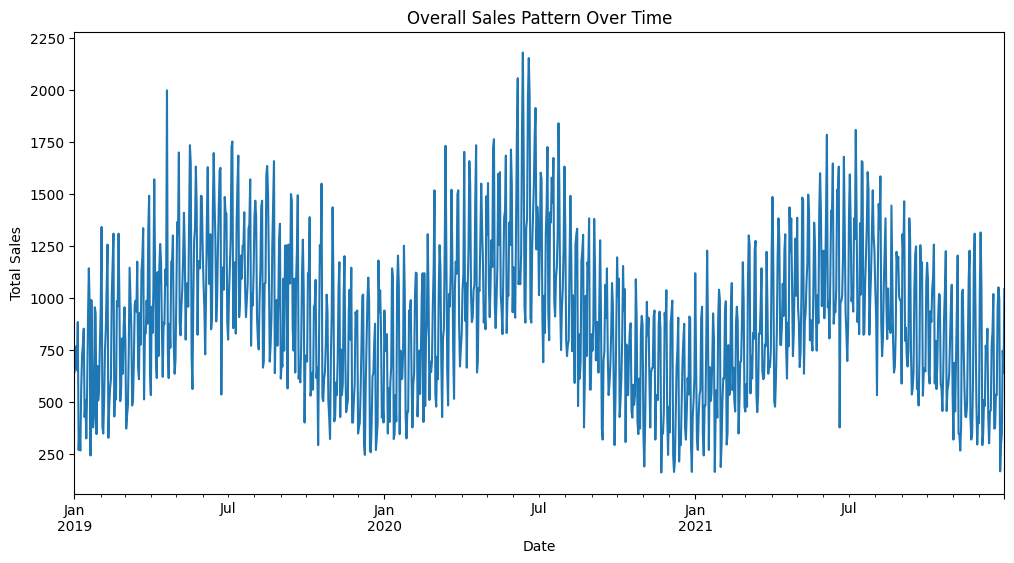

In [167]:
# a. Examine the overall sales pattern
plt.figure(figsize=(12, 6))
df.groupby('date')['sales'].sum().plot()
plt.title('Overall Sales Pattern Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


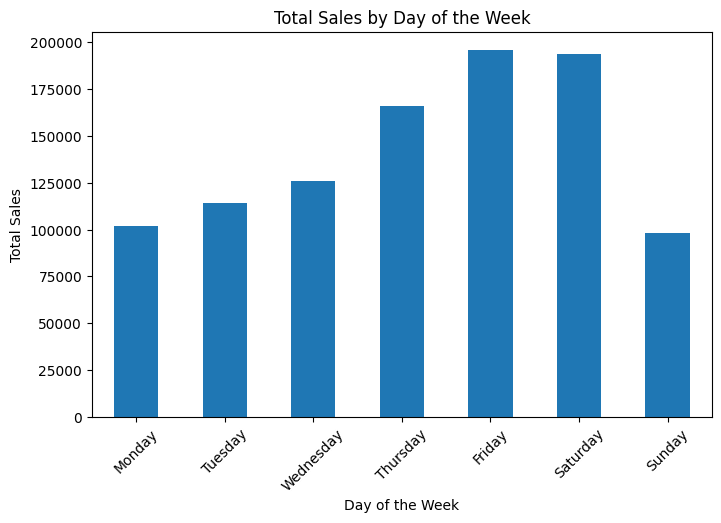

In [168]:
# b. Sales across different days of the week
df['day_of_week'] = df['date'].dt.day_name()
sales_by_day = df.groupby('day_of_week')['sales'].sum().reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
plt.figure(figsize=(8, 5))
sales_by_day.plot(kind='bar')
plt.title('Total Sales by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()

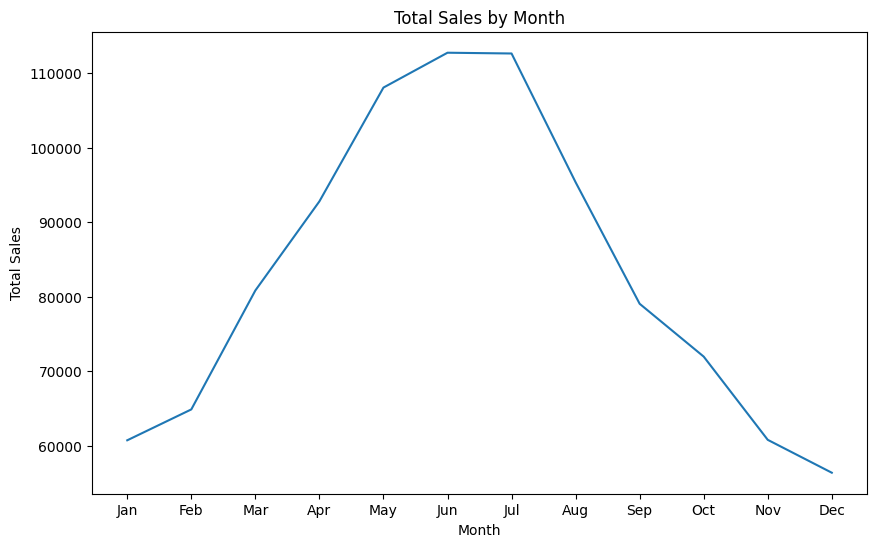

In [169]:
# c. Sales trends in different months
df['month'] = df['date'].dt.month
sales_by_month = df.groupby('month')['sales'].sum()
plt.figure(figsize=(10, 6))
sales_by_month.plot()
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

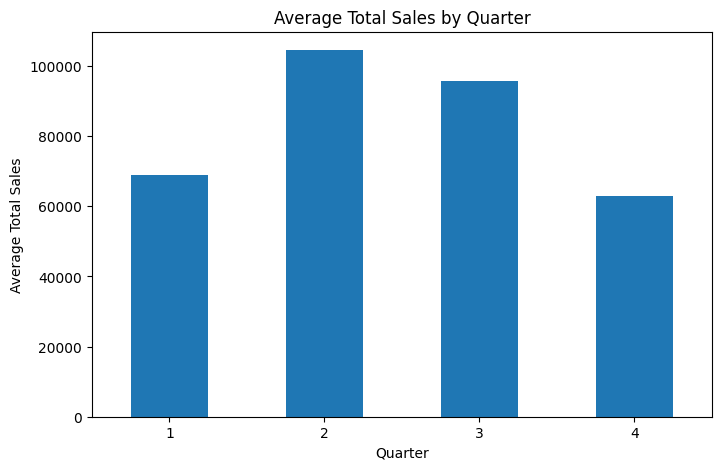

In [170]:
# d. Sales distribution across different quarters averaged over the years
df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter
sales_by_quarter_avg = df.groupby(['year', 'quarter'])['sales'].sum().groupby('quarter').mean()
plt.figure(figsize=(8, 5))
sales_by_quarter_avg.plot(kind='bar')
plt.title('Average Total Sales by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Total Sales')
plt.xticks(rotation=0)
plt.show()

In [171]:
# e. Compare the performances of the different restaurants.
sales_by_store = df.groupby('name_y')['sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by Store:")
print(sales_by_store)


Total Sales by Store:
name_y
Fou Cher          909878.38
Sweet Shack        86082.12
Corner Cafe          103.19
Beachfront Bar        60.36
Surfs Up              16.83
Bob's Diner            6.71
Name: sales, dtype: float64


In [172]:
# Sales for each restaurant across different years, months, and days
sales_by_store_year = df.groupby(['name_y', 'year'])['sales'].sum().unstack()
print("\nTotal Sales by Store and Year:")
print(sales_by_store_year)



Total Sales by Store and Year:
year                 2019       2020       2021
name_y                                         
Beachfront Bar      30.18       0.00      30.18
Bob's Diner          0.00       6.71       0.00
Corner Cafe         18.21      48.56      36.42
Fou Cher        307079.66  308849.80  293948.92
Surfs Up            16.83       0.00       0.00
Sweet Shack      29103.12   29599.86   27379.14


In [173]:
sales_by_store_month = df.groupby(['name_y', 'month'])['sales'].sum().unstack()
print("\nTotal Sales by Store and Month:")
print(sales_by_store_month)


Total Sales by Store and Month:
month                 1         2         3         4         5          6   \
name_y                                                                        
Beachfront Bar     15.09      0.00      0.00      0.00     15.09       0.00   
Bob's Diner         6.71      0.00      0.00      0.00      0.00       0.00   
Corner Cafe         0.00      6.07      0.00     12.14     12.14      18.21   
Fou Cher        55878.30  59048.70  73817.48  84623.26  98414.50  103275.78   
Surfs Up            5.61      0.00      0.00      0.00      0.00       0.00   
Sweet Shack      4821.30   5814.78   7012.80   8152.38   9613.38    9438.06   

month                  7         8         9         10        11        12  
name_y                                                                       
Beachfront Bar       0.00      0.00      0.00     15.09      0.00     15.09  
Bob's Diner          0.00      0.00      0.00      0.00      0.00      0.00  
Corner Cafe         12

In [174]:
sales_by_store_day = df.groupby(['name_y', 'day_of_week'])['sales'].sum().unstack().reindex(columns=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("\nTotal Sales by Store and Day of Week:")
print(sales_by_store_day)


Total Sales by Store and Day of Week:
day_of_week       Monday    Tuesday  Wednesday   Thursday     Friday  \
name_y                                                                 
Beachfront Bar     45.27       0.00       0.00       0.00       0.00   
Bob's Diner         0.00       0.00       0.00       6.71       0.00   
Corner Cafe        12.14      12.14      12.14      30.35       6.07   
Fou Cher        92390.74  104676.04  115270.46  151413.02  178731.30   
Surfs Up            0.00       0.00       5.61       5.61       0.00   
Sweet Shack      9438.06    9730.26   10752.96   14697.66   17093.70   

day_of_week      Saturday    Sunday  
name_y                               
Beachfront Bar       0.00     15.09  
Bob's Diner          0.00      0.00  
Corner Cafe         12.14     18.21  
Fou Cher        177383.88  90012.94  
Surfs Up             5.61      0.00  
Sweet Shack      16421.64   7947.84  


**Machine learning:**

In [175]:
df.head()

,store_id,name_x,kcal,cost,name_y,date,price,item_count,year,month,day_of_week,sales,quarter
0,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-01,6.71,0.0,2019,1,Tuesday,0.0,1
1,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-02,6.71,0.0,2019,1,Wednesday,0.0,1
2,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-03,6.71,0.0,2019,1,Thursday,0.0,1
3,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-04,6.71,0.0,2019,1,Friday,0.0,1
4,4,Chocolate Cake,554,6.71,Bob's Diner,2019-01-05,6.71,0.0,2019,1,Saturday,0.0,1


In [176]:
# f. Identify the most popular items overall and the stores where they are being sold.
popular_items_overall = df.groupby('name_x')['item_count'].sum().sort_values(ascending=False)
print("\nMost Popular Items Overall:")
print(popular_items_overall.head(10)) # Display top 10


Most Popular Items Overall:
name_x
Amazing Steak Dinner with Rolls      34439.0
Sweet Fruity Cake                     2946.0
Milk Cake                               17.0
Breaded Fish with Vegetables Meal        4.0
Fruity Frozen Cocktail                   3.0
Chocolate Cake                           1.0
Name: item_count, dtype: float64


In [177]:
# Stores where popular items are sold (requires filtering by item and then finding stores)
# Example for the most popular item (replace with the actual item name)

most_popular_item_name = popular_items_overall.index[0]
stores_selling_most_popular = df[df['name_x'] == most_popular_item_name]['name_y'].unique()
print(f"\nStores selling '{most_popular_item_name}':")
print(stores_selling_most_popular)


Stores selling 'Amazing Steak Dinner with Rolls':
['Fou Cher']


In [178]:
# Most popular item at each store
popular_item_by_store = df.groupby(['name_y', 'name_x'])['item_count'].sum().reset_index()
most_popular_item_per_store = popular_item_by_store.loc[popular_item_by_store.groupby('name_x')['item_count'].idxmax()]
print("\nMost Popular Item at Each Store:")
print(most_popular_item_per_store)


Most Popular Item at Each Store:
           name_y                             name_x  item_count
3        Fou Cher    Amazing Steak Dinner with Rolls     34439.0
0  Beachfront Bar  Breaded Fish with Vegetables Meal         4.0
1     Bob's Diner                     Chocolate Cake         1.0
4        Surfs Up             Fruity Frozen Cocktail         3.0
2     Corner Cafe                          Milk Cake        17.0
5     Sweet Shack                  Sweet Fruity Cake      2946.0


In [179]:
# g. Determine if the store with the highest sales volume is also making the most money per day
# Assuming the store with highest sales volume is the one identified in EDA (sales_by_store)
store_with_highest_sales = sales_by_store.index[0]


In [180]:
# Calculate average sales per day for each store
avg_sales_per_day_by_store = df.groupby('name_y')['sales'].mean()
print("\nAverage Sales Per Day by Store:")
print(avg_sales_per_day_by_store.sort_values(ascending=False))



Average Sales Per Day by Store:
name_y
Fou Cher          830.181004
Sweet Shack        78.542080
Corner Cafe         0.094151
Beachfront Bar      0.055073
Surfs Up            0.015356
Bob's Diner         0.006122
Name: sales, dtype: float64


In [181]:
# Compare the average sales per day of the highest sales volume store
print(f"\nAverage sales per day for '{store_with_highest_sales}':")
print(avg_sales_per_day_by_store[store_with_highest_sales])



Average sales per day for 'Fou Cher':
830.1810036496352


In [182]:
# h. Identify the most expensive item at each restaurant and find out its calorie count
most_expensive_item_by_store = df.loc[df.groupby('name_y')['price'].idxmax()]
print("\nMost Expensive Item at Each Restaurant:")
print(most_expensive_item_by_store[['name_x', 'name_y', 'price', 'kcal']])


Most Expensive Item at Each Restaurant:
                                 name_x          name_y  price  kcal
1096  Breaded Fish with Vegetables Meal  Beachfront Bar  15.09   772
0                        Chocolate Cake     Bob's Diner   6.71   554
4384                          Milk Cake     Corner Cafe   6.07   583
3288    Amazing Steak Dinner with Rolls        Fou Cher  26.42   763
5480             Fruity Frozen Cocktail        Surfs Up   5.61   537
2192                  Sweet Fruity Cake     Sweet Shack  29.22   931


**Forecasting using machine learning algorithms:**


a. Build and compare linear regression, random forest, and XGBoost models for predictions

b• Generate necessary features for the development of these models, like day of the week,quarter of the year, month, year, day of the month and so on

c• Use the data from the last six months as the testing data

d• Compute the root mean square error (RMSE) values for each model to compare their
performances

e• Use the best-performing models to make a forecast for the next year

In [183]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error
import numpy as np

In [184]:
# Generate features for forecasting
df['day_of_month'] = df['date'].dt.day
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear

In [185]:
# Prepare data for forecasting (focus on total daily sales for simplicity)
daily_sales = df.groupby('date')['sales'].sum().reset_index()


In [186]:
# Generate features for the daily sales data
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['day_of_week'] = daily_sales['date'].dt.dayofweek # Monday=0, Sunday=6
daily_sales['quarter'] = daily_sales['date'].dt.quarter
daily_sales['day_of_month'] = daily_sales['date'].dt.day
daily_sales['week_of_year'] = daily_sales['date'].dt.isocalendar().week.astype(int)
daily_sales['day_of_year'] = daily_sales['date'].dt.dayofyear


In [187]:
# Create dummy variables for categorical features
daily_sales = pd.get_dummies(daily_sales, columns=['day_of_week', 'month', 'quarter'])

In [188]:
# Split data into training and testing sets (last six months for testing)
# Find the date six months ago from the latest date in the data
latest_date = daily_sales['date'].max()
six_months_ago = latest_date - pd.DateOffset(months=6)

train_data = daily_sales[daily_sales['date'] <= six_months_ago]
test_data = daily_sales[daily_sales['date'] > six_months_ago]

X_train = train_data.drop(['date', 'sales'], axis=1)
y_train = train_data['sales']
X_test = test_data.drop(['date', 'sales'], axis=1)
y_test = test_data['sales']




In [189]:
# Align columns - essential if one split is missing a dummy variable category
train_cols = list(X_train.columns)
test_cols = list(X_test.columns)

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    X_test[c] = 0

missing_in_train = set(test_cols) - set(train_cols)
for c in missing_in_train:
    X_train[c] = 0

X_test = X_test[train_cols] # Ensure the order of columns is the same

In [190]:
# Build and compare models
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
print("\nLinear Regression RMSE:", lr_rmse)


Linear Regression RMSE: 192.61368518736722


In [191]:
# Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 170.52040841310688


In [192]:
# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print("XGBoost RMSE:", xgb_rmse)

XGBoost RMSE: 197.37097503717064


In [193]:
# Determine the best performing model
rmse_values = {'Linear Regression': lr_rmse, 'Random Forest': rf_rmse, 'XGBoost': xgb_rmse}
best_model_name = min(rmse_values, key=rmse_values.get)
print(f"\nBest performing model based on RMSE: {best_model_name}")



Best performing model based on RMSE: Random Forest


In [194]:
# Use the best model to forecast for the next year
# Create a dataframe for the next year's dates and generate features

latest_date = daily_sales['date'].max() # Get latest date from daily_sales
next_year_dates = pd.date_range(start=latest_date + pd.Timedelta(days=1), periods=365, freq='D')
forecast_data = pd.DataFrame({'date': next_year_dates})

# Keep the dates separate BEFORE generating features and aligning columns
forecast_dates = forecast_data['date']

forecast_data['year'] = forecast_data['date'].dt.year
forecast_data['month'] = forecast_data['date'].dt.month
forecast_data['day'] = forecast_data['date'].dt.day
forecast_data['day_of_week'] = forecast_data['date'].dt.dayofweek
forecast_data['quarter'] = forecast_data['date'].dt.quarter
forecast_data['day_of_month'] = forecast_data['date'].dt.day
forecast_data['week_of_year'] = forecast_data['date'].dt.isocalendar().week.astype(int)
forecast_data['day_of_year'] = forecast_data['date'].dt.dayofyear


In [195]:
# Create dummy variables for forecast data and align columns
forecast_data = pd.get_dummies(forecast_data, columns=['day_of_week', 'month', 'quarter'])

In [196]:
# Ensure forecast data has the same columns as training data (fill missing with 0)
# train_cols should be defined from X_train before this point
train_cols_no_date = [col for col in train_cols if col != 'date'] # Exclude 'date' from train_cols
forecast_cols = list(forecast_data.columns)
missing_in_forecast = set(train_cols_no_date) - set(forecast_cols)
for c in missing_in_forecast:
    forecast_data[c] = 0

In [197]:
# Now, filter forecast_data to match the columns in X_train (excluding 'date')
forecast_data = forecast_data[train_cols_no_date]


In [198]:
forecast_data.head()

,year,day,day_of_month,week_of_year,day_of_year,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,...,month_7,month_8,month_9,month_10,month_11,month_12,quarter_1,quarter_2,quarter_3,quarter_4
0,2022,1,1,52,1,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2022,2,2,52,2,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,2022,3,3,1,3,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,2022,4,4,1,4,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,2022,5,5,1,5,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [199]:
# Make predictions using the best model
if best_model_name == 'Linear Regression':
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = xgb_model

next_year_forecast = best_model.predict(forecast_data)




In [200]:
# Add the forecast to a new DataFrame that includes the preserved dates
forecast_results = pd.DataFrame({'date': forecast_dates, 'forecasted_sales': next_year_forecast})

print("\nForecast for the next year:")
print(forecast_results.head()) # Display the first few forecast days


Forecast for the next year:
        date  forecasted_sales
0 2022-01-01          799.7952
1 2022-01-02          357.6536
2 2022-01-03          386.0616
3 2022-01-04          406.1530
4 2022-01-05          578.8921


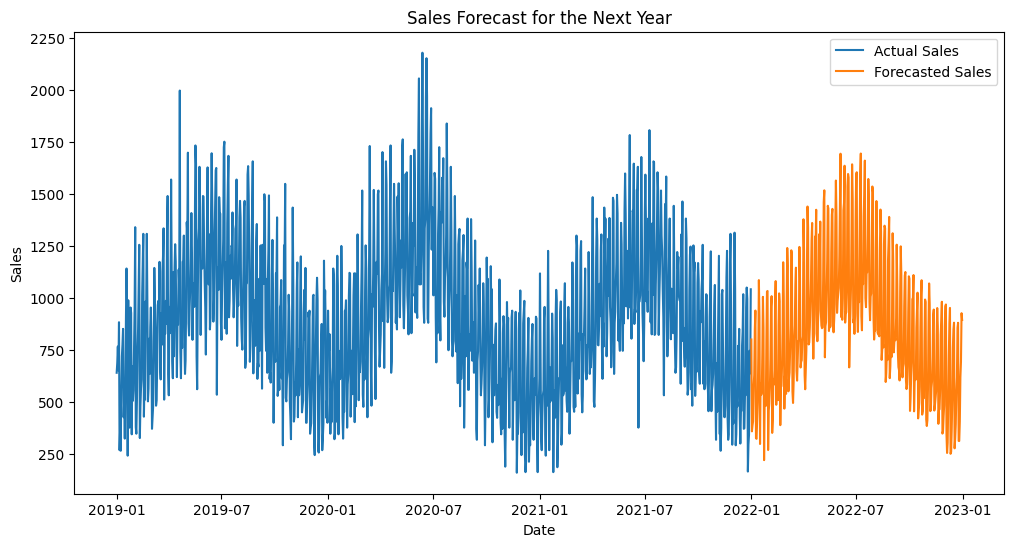

In [201]:
# visualize the forecast

plt.figure(figsize=(12, 6))
plt.plot(daily_sales['date'], daily_sales['sales'], label='Actual Sales')
plt.plot(forecast_results['date'], forecast_results['forecasted_sales'], label='Forecasted Sales')
plt.title('Sales Forecast for the Next Year')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()